In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [60]:
df=pd.read_csv('weight-height.csv')

In [61]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [62]:
df.drop('Gender', axis=1, inplace=True)

Text(0, 0.5, 'Height')

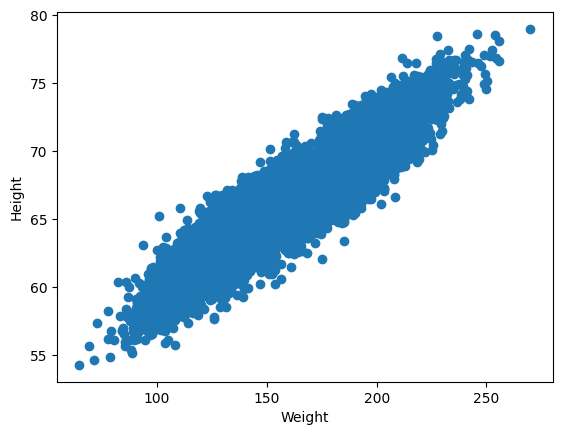

In [63]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [64]:

df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


c:\Users\Tapas\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


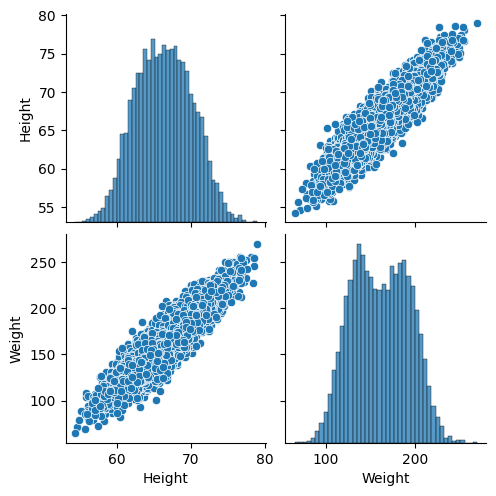

In [65]:

import seaborn as sns
sns.pairplot(df)

In [66]:

X=df[['Weight']] 
y=df['Height'] 


In [67]:
X_series=df['Weight']
np.array(X_series).shape

(10000,)

In [68]:
np.array(y).shape

(10000,)

In [69]:

from sklearn.model_selection import train_test_split


In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [71]:
X_test

,Weight
6252,173.115813
4684,195.162042
1731,170.217451
4742,215.049660
4521,182.721452
...,...
4862,203.763292
7025,155.915544
7647,123.862430
7161,165.324899


In [72]:

from sklearn.linear_model import LinearRegression

In [73]:
regression=LinearRegression()

In [74]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [0.11092798]
Intercept: 48.46334599483153


Text(0, 0.5, 'weight-height.csv')

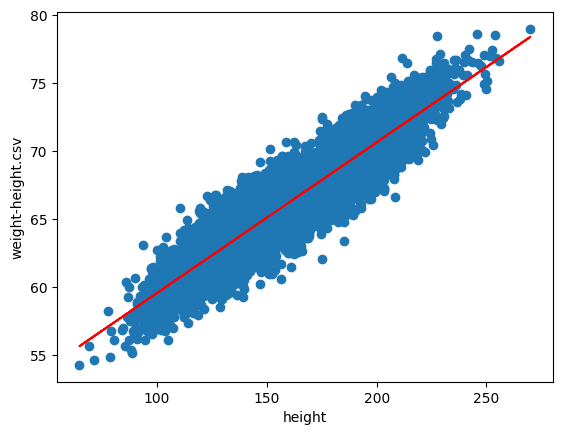

In [76]:

plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')
plt.xlabel("height")
plt.ylabel("weight-height.csv")

In [77]:

y_pred=regression.predict(X_test)

In [78]:

from sklearn.metrics import mean_absolute_error,mean_squared_error

In [79]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.124500293128046
1.16186862410503
1.457566565590761


### Using OLS

In [88]:
import numpy as np

class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self, X_train, y_train):

        # convert to numpy
        X = np.array(X_train).reshape(-1)
        y = np.array(y_train).reshape(-1)

        x_mean = X.mean()
        y_mean = y.mean()

        num = 0
        den = 0
        
        for i in range(len(X)):
            num += (X[i] - x_mean) * (y[i] - y_mean)
            den += (X[i] - x_mean) ** 2
        
        self.m = num / den
        self.b = y_mean - self.m * x_mean

        print("m =", self.m)
        print("b =", self.b)
    
    def predict(self, X_test):
        X = np.array(X_test).reshape(-1)
        return self.m * X + self.b


In [89]:
Lr=MeraLR()

In [90]:
y_train.shape

(7500,)

In [91]:
X_train.shape

(7500, 1)

In [92]:
Lr.fit(X_train,y_train)

m = 0.11092797521015338
b = 48.463345994831535
